# 02 — Learned-rates model

Replaces EVE's central weakness: instead of the operator *informing* the
attendance proportion per response type (article table 27), the rates are
**estimated from data** (`src/model.py`):

1. Per-response rates, pooled from the field experiment (table 25);
2. A calibration factor `k` per size class, fitted on tables 7–10.

`rate[size][type] = experiment_rate(type) × k(size)`

**Honest caveats:** n=20 events, in-sample evaluation. This is a v1 calibration —
the tool (`app/`) logs new events precisely to refit it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import baseline
import model

coef = model.fit()
rates = pd.DataFrame(coef["rates"]).T[list(model.RESPONSE_TYPES)]
rates.style.format("{:.3f}").set_caption("Learned rates: expected attendance per response")

,confirmed,maybe,declined,no_reply
micro,0.850,0.381,0.000,0.036
small,0.554,0.248,0.000,0.023
medium,0.138,0.062,0.000,0.006
large,0.151,0.068,0.000,0.006


The rates tell the same story as the EDA: a confirmed guest at a micro event
shows up ~85% of the time; at a large event, ~15%. "No reply" never exceeds ~4%
— but at large events it is the bulk of the invited, so it still matters.

In [2]:
ev = model.evaluate(coef)
res = pd.DataFrame(ev["rows"])
res["abs_error"] = (res["predicted"] - res["actual"]).abs()
print(f"In-sample, n={len(res)}: MAE {ev['mae']:.1f} | MAPE {ev['mape_pct']:.1f}%")
res.sort_values("abs_error", ascending=False).head(8)

In-sample, n=20: MAE 34.4 | MAPE 24.4%


,set,id,size,predicted,actual,abs_error
0,size,large-1,large,302.2,167,135.2
2,size,large-3,large,234.5,351,116.5
4,size,medium-1,medium,102.2,182,79.8
3,size,large-4,large,359.0,425,66.0
6,size,medium-3,medium,138.6,82,56.6
1,size,large-2,large,287.3,240,47.3
7,size,medium-4,medium,103.0,61,42.0
10,size,small-3,small,149.3,190,40.7


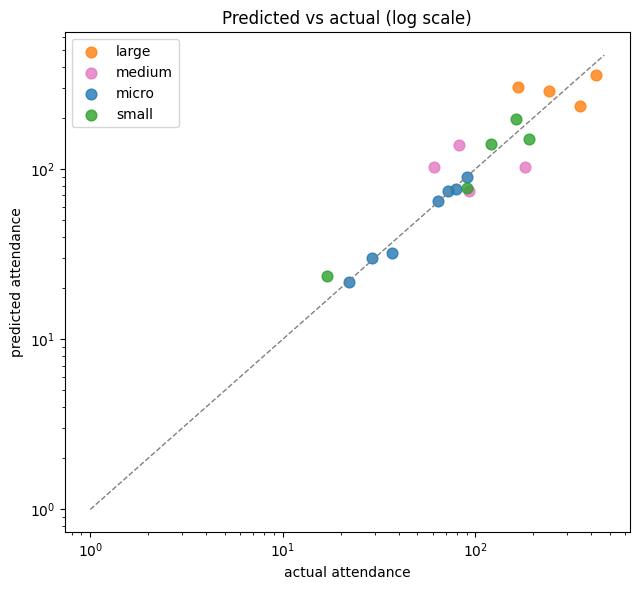

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 6))
colors = {"micro": "tab:blue", "small": "tab:green", "medium": "tab:pink", "large": "tab:orange"}
for size, g in res.groupby("size"):
    ax.scatter(g["actual"], g["predicted"], label=size, color=colors[size], s=60, alpha=.8)
lim = max(res["actual"].max(), res["predicted"].max()) * 1.1
ax.plot([1, lim], [1, lim], ls="--", c="gray", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("actual attendance"); ax.set_ylabel("predicted attendance")
ax.set_title("Predicted vs actual (log scale)")
ax.legend()
plt.tight_layout()

## Model vs baseline on the field experiment

The baseline uses the proportions the operator hand-tuned **after each event** —
an advantage the model does not have.

In [4]:
bl = pd.DataFrame(baseline.run())
md = res[res["set"] == "experiment"].reset_index(drop=True)

comp = pd.DataFrame({
    "date": bl["date"],
    "actual": bl["attendance"],
    "baseline (operator)": bl["estimate"],
    "article": bl["article_prediction"],
    "model (learned)": md["predicted"].round(0).astype(int),
})

def mae_col(c):
    return (comp[c] - comp["actual"]).abs().mean()

display(comp)
pd.DataFrame({"MAE": {c: mae_col(c) for c in ["baseline (operator)", "article", "model (learned)"]}}).round(2)

,date,actual,baseline (operator),article,model (learned)
0,2013-05-05,17,22,21,24
1,2013-05-12,22,20,21,22
2,2013-05-20,29,29,23,30
3,2013-05-26,37,32,32,32


,MAE
baseline (operator),3.00
article,4.00
model (learned),3.25


### Conclusions

- On the experiment the learned model nearly ties the hand-tuned baseline
  (MAE ~3.25 vs 3.0) — but needed **no** operator-supplied proportion, and the
  baseline can't even run on the 16 size events (no operator proportions exist).
- Medium/large events carry high error (overall MAPE 24%): 4 events per class is
  little and the behavior is heterogeneous. That's where new data helps most.
- Coefficients exported to `data/model_coefficients.json` — consumed by the
  tool (`app/`) and the dashboard (`reports/`).

In [5]:
out = model.export(coef, ev)
print(f"Coefficients exported: {out}")

Coefficients exported: /Users/antonio/git/Data/projects/event-attendance-prediction/data/model_coefficients.json
